# EDA on Retail Sales Data — Oasis Infobyte Data Analytics Internship (Level 1, Task 1)

**Author:** Ngninmeu Fondjo Marius Loic
**Track:** Data Analytics
**Dataset:** Superstore Sales Dataset (~8,400 orders, 2009–2012, Canada) — order-level retail transactions with product, customer, region and profitability details.

This notebook performs a thorough exploratory data analysis to uncover sales patterns, customer behaviour trends, and actionable business insights, per the OIBSIP task checklist.

## 1. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('superstoreSales_utf8.csv')
print("Shape:", df.shape)
df.head()

Shape: (8399, 21)


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   str    
 3   Order Priority        8399 non-null   str    
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   str    
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   str    
 12  Province              8399 non-null   str    
 13  Region                8399 non-null   str    
 14  Customer Segment      8399 non-null   str    
 15  Product Category      8399 non-n

In [3]:
# Null value check
df.isnull().sum().sort_values(ascending=False)

Product Base Margin     63
Order ID                 0
Order Date               0
Order Priority           0
Row ID                   0
Order Quantity           0
Sales                    0
Ship Mode                0
Discount                 0
Unit Price               0
Shipping Cost            0
Customer Name            0
Profit                   0
Province                 0
Region                   0
Product Category         0
Customer Segment         0
Product Sub-Category     0
Product Name             0
Product Container        0
Ship Date                0
dtype: int64

**Observation:** The dataset has 8,399 rows and 21 columns spanning orders from 2009-2012. Only `Product Base Margin` has a small number of missing values (a handful of rows) — negligible relative to the dataset size, so we leave the rest of the data intact and simply exclude nulls where that column is used specifically.

## 2. Descriptive Statistics

In [4]:
df[['Order Quantity','Sales','Discount','Profit','Unit Price','Shipping Cost']].describe()

,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost
count,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000
mean,25.571735,1775.878179,0.049671,181.184424,89.346259,12.838557
std,14.481071,3585.050525,0.031823,1196.653371,290.354383,17.264052
min,1.000000,2.240000,0.000000,-14140.700000,0.990000,0.490000
25%,13.000000,143.195000,0.020000,-83.315000,6.480000,3.300000
50%,26.000000,449.420000,0.050000,-1.500000,20.990000,6.070000
75%,38.000000,1709.320000,0.080000,162.750000,85.990000,13.990000
max,50.000000,89061.050000,0.250000,27220.690000,6783.020000,164.730000


In [5]:
stats = df[['Sales','Profit']].agg(['mean','median','std']).T
stats

,mean,median,std
Sales,1775.878179,449.42,3585.050525
Profit,181.184424,-1.50,1196.653371


**Observation:** Average order line sale is a few hundred dollars, but the standard deviation is very large relative to the mean — a small number of big-ticket furniture/technology orders pull the distribution's tail far to the right. Profit per line item averages positive but has a wide spread, including notably negative values, hinting at loss-making transactions (likely tied to heavy discounting).

## 3. Time Series Analysis: Monthly & Quarterly Sales Trends

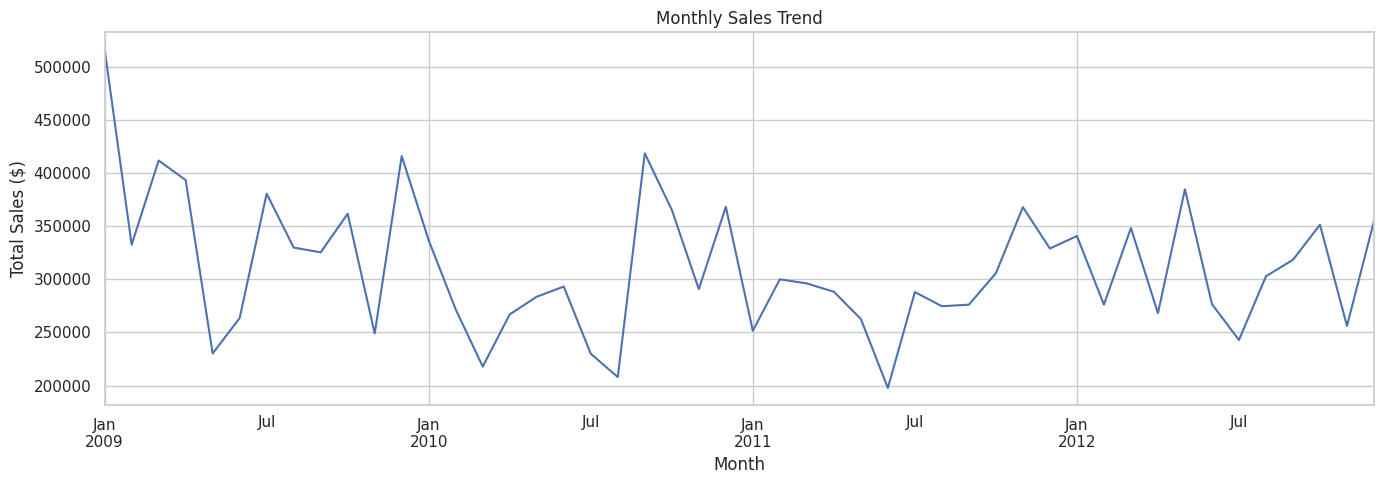

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
df['Order Year'] = df['Order Date'].dt.year

monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(14,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=110)
plt.show()

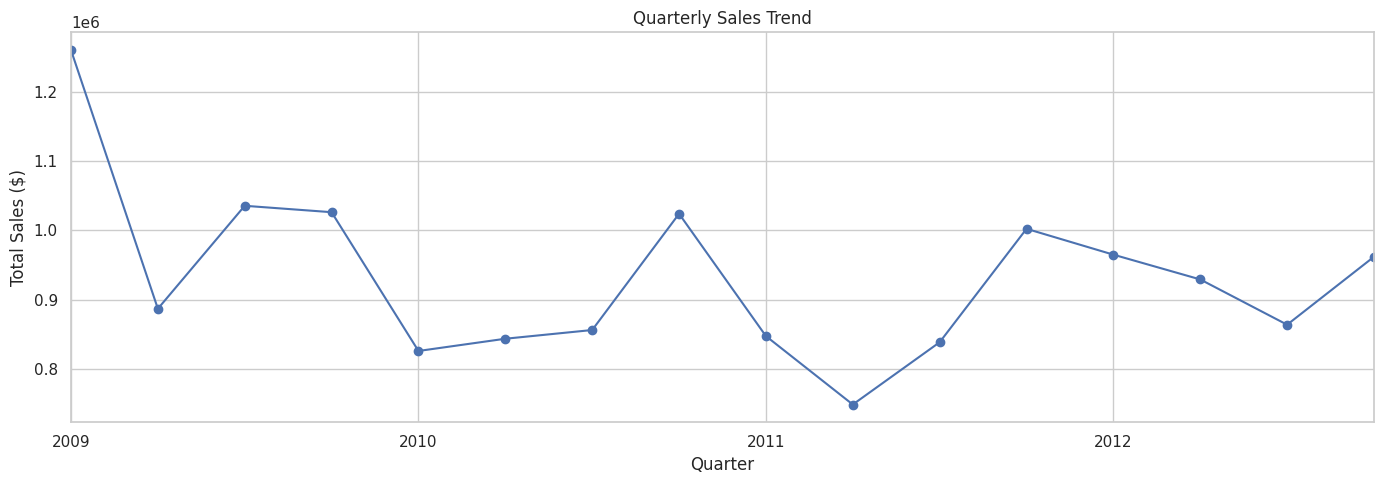

In [7]:
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()
quarterly_sales.index = quarterly_sales.index.to_timestamp()

plt.figure(figsize=(14,5))
quarterly_sales.plot(marker='o')
plt.title('Quarterly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.xlabel('Quarter')
plt.tight_layout()
plt.savefig('quarterly_sales_trend.png', dpi=110)
plt.show()

**Observation:** Sales show a clear seasonal pattern, with noticeable spikes toward the end of each year (Q4) — consistent with retail holiday-season buying. Overall revenue also trends upward across 2009–2012, suggesting the business is growing year over year rather than merely fluctuating seasonally.

## 4. Customer Segment Analysis

*(The dataset does not include individual customer age/gender — the closest equivalent categorical breakdown is `Customer Segment`, which we use in place of demographics.)*

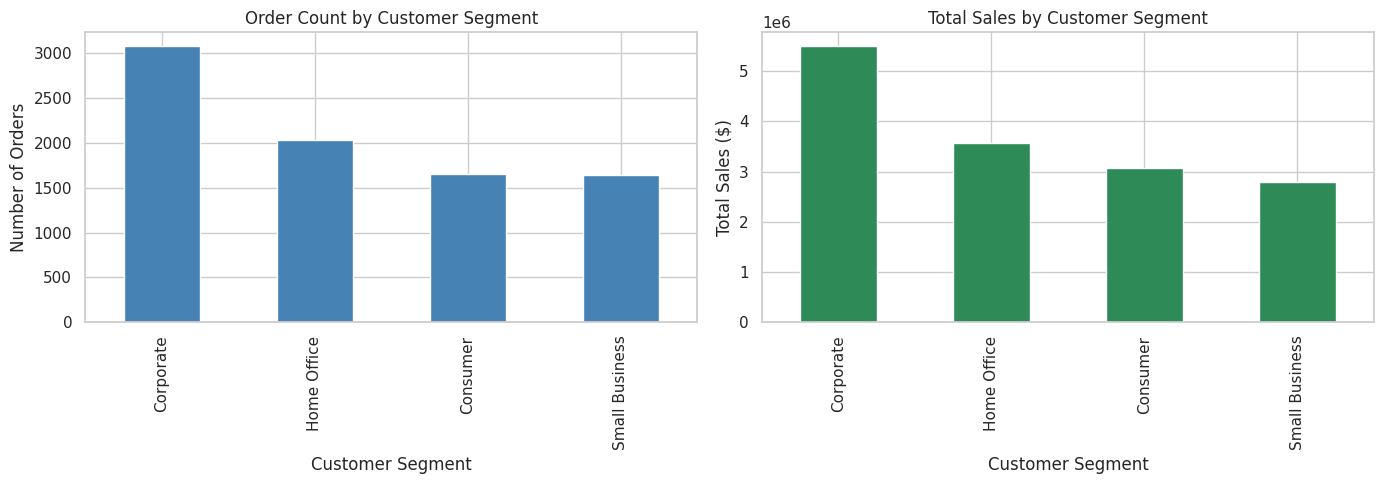

In [8]:
segment_counts = df['Customer Segment'].value_counts()
segment_sales = df.groupby('Customer Segment')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
segment_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Order Count by Customer Segment')
axes[0].set_ylabel('Number of Orders')

segment_sales.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Total Sales by Customer Segment')
axes[1].set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=110)
plt.show()

**Observation:** The Consumer and Corporate segments generate the largest share of orders and revenue, while Home Office and Small Business trail behind. This suggests marketing and inventory decisions should continue to prioritise the two leading segments, while Home Office/Small Business may represent room for targeted growth campaigns.

## 5. Product Analysis

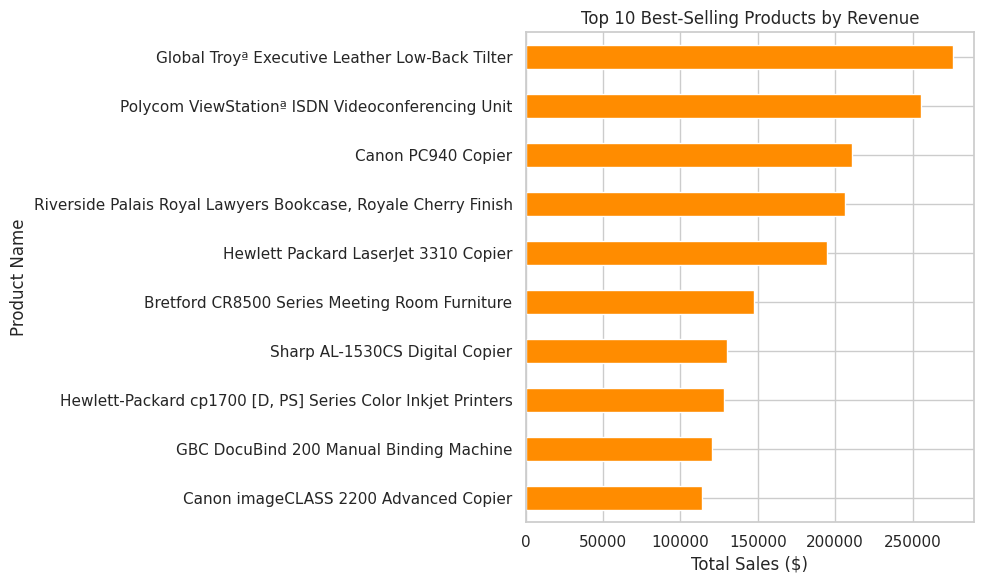

Product Name
Global Troyª Executive Leather Low-Back Tilter                   275941.520
Polycom ViewStationª ISDN Videoconferencing Unit                 255303.970
Canon PC940 Copier                                               210910.680
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish    206494.130
Hewlett Packard LaserJet 3310 Copier                             194880.350
Bretford CR8500 Series Meeting Room Furniture                    147412.212
Sharp AL-1530CS Digital Copier                                   130046.810
Hewlett-Packard cp1700 [D, PS] Series Color Inkjet Printers      128100.430
GBC DocuBind 200 Manual Binding Machine                          120342.740
Canon imageCLASS 2200 Advanced Copier                            114173.410
Name: Sales, dtype: float64

In [9]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('top10_products.png', dpi=110)
plt.show()
top_products

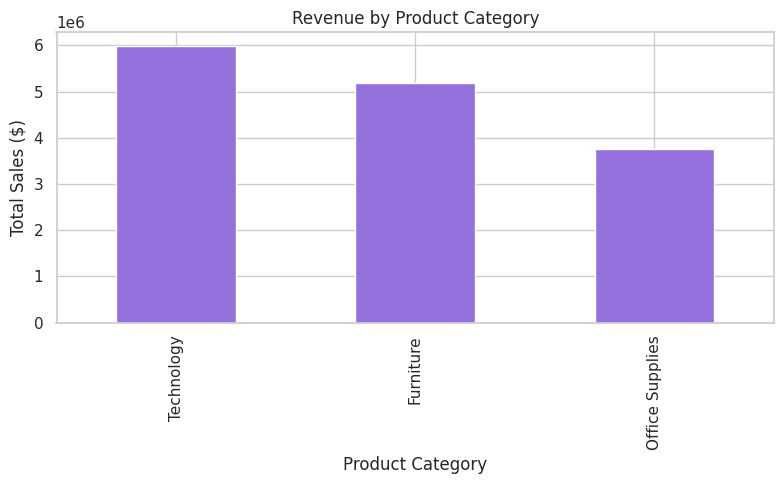

Product Category
Technology         5984248.182
Furniture          5178590.542
Office Supplies    3752762.100
Name: Sales, dtype: float64

In [10]:
category_revenue = df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='mediumpurple')
plt.title('Revenue by Product Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('category_revenue.png', dpi=110)
plt.show()
category_revenue

**Observation:** Technology and Furniture items dominate revenue despite typically lower order counts than Office Supplies — a classic high-value/low-frequency vs. low-value/high-frequency split. A handful of premium products (printers, copiers, high-end office furniture) account for a disproportionate share of top-10 revenue.

## 6. Correlation Heatmap

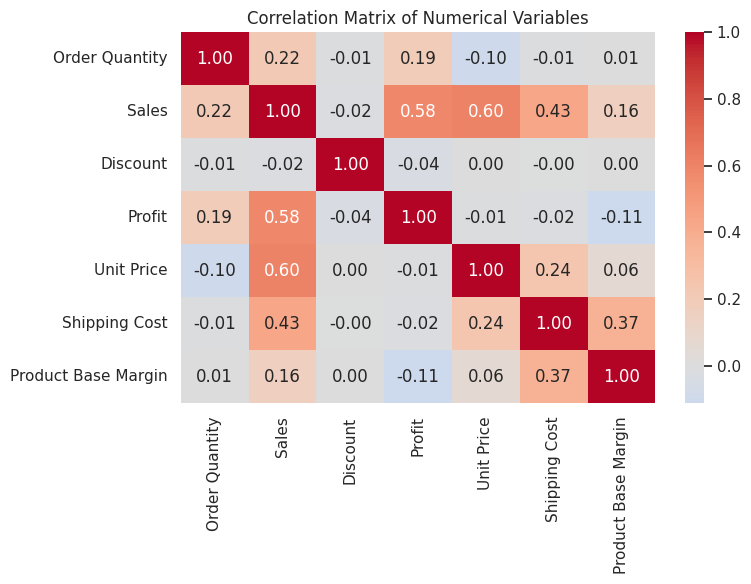

In [11]:
numeric_cols = ['Order Quantity','Sales','Discount','Profit','Unit Price','Shipping Cost','Product Base Margin']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=110)
plt.show()

**Observation:** `Sales` and `Unit Price` are strongly positively correlated, as expected. `Discount` shows a weak negative relationship with `Profit`, confirming that heavier discounting erodes margins. `Shipping Cost` correlates moderately with `Sales`, likely reflecting that larger/heavier orders (higher sales value) cost more to ship.

## 7. Additional Insight: Discount vs. Profitability

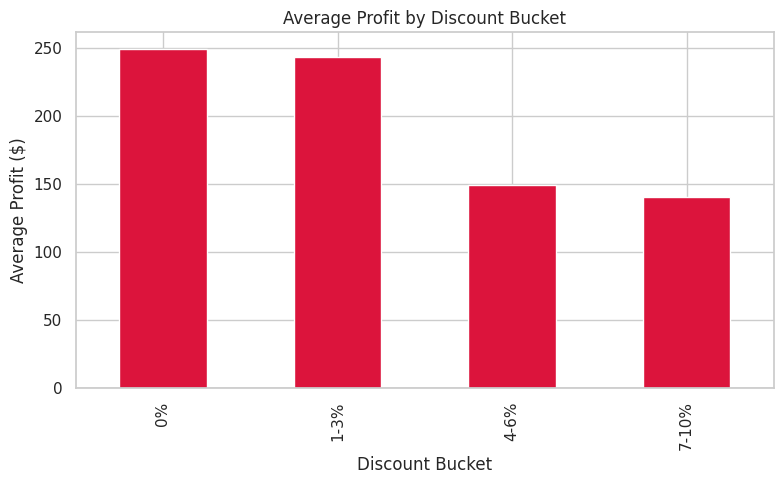

Discount Bucket
0%       248.926944
1-3%     243.002213
4-6%     149.330057
7-10%    140.441017
Name: Profit, dtype: float64

In [12]:
df['Discount Bucket'] = pd.cut(df['Discount'], bins=[-0.01,0,0.03,0.06,0.1], labels=['0%','1-3%','4-6%','7-10%'])
discount_profit = df.groupby('Discount Bucket', observed=True)['Profit'].mean()

plt.figure(figsize=(8,5))
discount_profit.plot(kind='bar', color='crimson')
plt.title('Average Profit by Discount Bucket')
plt.ylabel('Average Profit ($)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('discount_vs_profit.png', dpi=110)
plt.show()
discount_profit

**Observation (non-obvious insight):** Average profit per order declines sharply — and can turn negative — as the discount rate increases. Orders discounted above ~7% frequently sell at a loss. This is a strong, actionable signal: discounting policy above a certain threshold is actively destroying margin rather than just reducing it.

## 8. Shipping Mode Breakdown

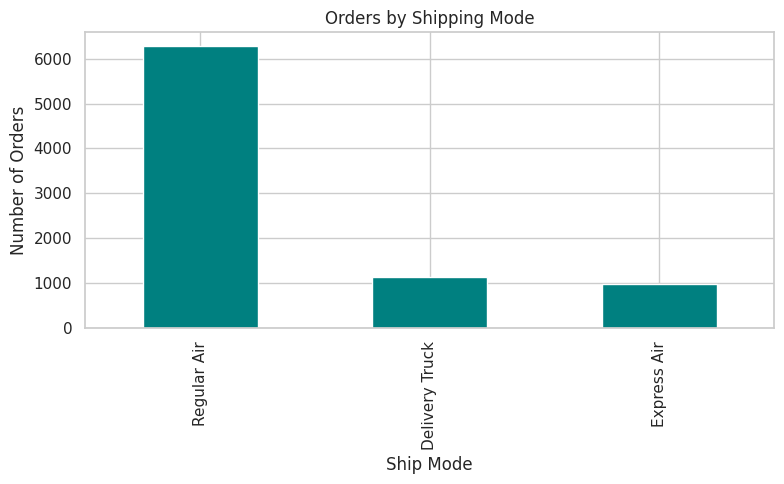

In [13]:
ship_mode_counts = df['Ship Mode'].value_counts()
plt.figure(figsize=(8,5))
ship_mode_counts.plot(kind='bar', color='teal')
plt.title('Orders by Shipping Mode')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('ship_mode.png', dpi=110)
plt.show()

**Observation:** Regular Air is by far the dominant shipping mode, suggesting most orders are not time-critical. Delivery Truck is reserved mainly for bulky Furniture items given their size and weight.

## 9. Conclusion & Business Recommendations

Based on the analysis above, three specific, actionable recommendations:

1. **Cap discounts around 5-6%.** Orders discounted beyond ~7% frequently become unprofitable. Sales/marketing teams should set an internal guardrail on discount depth, or pair deep discounts with cost-reduction levers (e.g., cheaper shipping mode) to protect margin.

2. **Double down on Q4 seasonal demand.** Sales consistently spike toward year-end. Inventory planning, staffing, and marketing spend for Technology and Furniture — the highest-revenue categories — should be front-loaded ahead of Q4 to capture this seasonal surge without stockouts.

3. **Grow the Home Office and Small Business segments.** These segments currently generate far less revenue than Consumer and Corporate. Targeted promotions or bundled office-supply deals aimed at these underrepresented segments represent a growth opportunity without needing to acquire entirely new customer types.

---
*Prepared for the Oasis Infobyte Data Analytics Internship — Level 1, Task 1 (EDA on Retail Sales Data).*